# Notebook 1: Setup & Preprocessing

**What this does (in simple terms):**

Think of this as preparing ingredients before cooking.
Raw audio files come in different lengths and formats.
This notebook makes them all the same — same length, same format —
so the model can process them in neat batches later.

Steps:
1. Connect Google Drive (to save checkpoints later)
2. Download the ASVspoof 2019 dataset to Colab's fast local disk
3. Analyze audio durations (to pick the right length)
4. Preprocess all audio: convert to mono, resample to 16kHz, pad/truncate to 6s
5. Save preprocessed files
6. Delete raw data to free up space

**Run this on Colab. Takes ~20-30 minutes total.**

## 1.1 Mount Google Drive & Install Libraries

In [10]:
# Mount Google Drive — checkpoints and results will be saved here
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/deepfake_project/checkpoints', exist_ok=True)
os.makedirs('/content/drive/MyDrive/deepfake_project/results', exist_ok=True)
print("Google Drive mounted!")
print("Checkpoint dir: /content/drive/MyDrive/deepfake_project/checkpoints")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted!
Checkpoint dir: /content/drive/MyDrive/deepfake_project/checkpoints


In [11]:
# Install required libraries (run once per session)
!pip install librosa soundfile tqdm matplotlib pandas -q

## 1.2 Download ASVspoof 2019 LA Dataset

This downloads the dataset directly to Colab's local disk (~100GB available).
The download takes ~5-10 minutes depending on connection speed.

In [14]:
# from pathlib import Path

# INPUT_ROOT = Path("/content/drive/MyDrive/LA")
# PREPROCESSED_DIR = Path("/content/preprocessed")
# PREPROCESSED_DIR.mkdir(exist_ok=True)

# # Verify the folder structure
# for name in ["ASVspoof2019_LA_train/flac", "ASVspoof2019_LA_dev/flac",
#              "ASVspoof2019_LA_eval/flac", "ASVspoof2019_LA_cm_protocols"]:
#     folder = INPUT_ROOT / name
#     count = len(list(folder.glob("*"))) if folder.exists() else 0
#     status = "✓" if count > 0 else "✗ NOT FOUND"
#     print(f"{name}: {count} files {status}")

ASVspoof2019_LA_train/flac: 25380 files ✓
ASVspoof2019_LA_dev/flac: 24991 files ✓
ASVspoof2019_LA_eval/flac: 71944 files ✓
ASVspoof2019_LA_cm_protocols: 3 files ✓


In [22]:
# !cp -r /content/drive/MyDrive/LA /content/raw_data/LA

In [26]:
import os
from pathlib import Path

PREPROCESSED_DIR = Path("/content/preprocessed")
PREPROCESSED_DIR.mkdir(exist_ok=True)

# Download from Kaggle (fast on Colab)
!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")

print(f"Downloaded to: {path}")
print("\nContents:")
!ls "{path}"

Resuming download from 3444572160 bytes (21877250984 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/1.archive (3444572160/25321823144) bytes left.


100%|██████████| 23.6G/23.6G [19:45<00:00, 18.5MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1

Contents:
asvspoof2019_evaluation_plan.pdf	     LA		       PA
asvspoof2019_Interspeech2019_submission.pdf  LICENSE_text.txt  README.txt


In [37]:
INPUT_ROOT = Path("/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1/LA/LA")

In [38]:
# Verify the folder structure
TRAIN_AUDIO = INPUT_ROOT / "ASVspoof2019_LA_train" / "flac"
DEV_AUDIO = INPUT_ROOT / "ASVspoof2019_LA_dev" / "flac"
EVAL_AUDIO = INPUT_ROOT / "ASVspoof2019_LA_eval" / "flac"
PROTOCOL_DIR = INPUT_ROOT / "ASVspoof2019_LA_cm_protocols"

for name, path in [("Train audio", TRAIN_AUDIO), ("Dev audio", DEV_AUDIO),
                    ("Eval audio", EVAL_AUDIO), ("Protocols", PROTOCOL_DIR)]:
    exists = path.exists()
    count = len(list(path.glob("*"))) if exists else 0
    print(f"{name}: {'FOUND' if exists else 'MISSING'} ({count} files)")

Train audio: FOUND (25380 files)
Dev audio: FOUND (24986 files)
Eval audio: FOUND (71933 files)
Protocols: FOUND (3 files)


## 1.3 Duration Analysis

Before we decide how long to make each audio clip, let's look at
how long the actual audio files are. This helps us pick a smart
cutoff instead of guessing.

In [39]:
import numpy as np
import librosa
from tqdm import tqdm
import matplotlib.pyplot as plt

TARGET_SR = 16000

AUDIO_FOLDERS = {
    "Train": INPUT_ROOT / "ASVspoof2019_LA_train" / "flac",
    "Dev": INPUT_ROOT / "ASVspoof2019_LA_dev" / "flac",
    "Eval": INPUT_ROOT / "ASVspoof2019_LA_eval" / "flac",
}

all_durations = []

for split_name, folder in AUDIO_FOLDERS.items():
    files = list(folder.glob("*.flac"))
    durations = []
    for f in tqdm(files, desc=f"Scanning {split_name}"):
        duration = librosa.get_duration(path=str(f))
        durations.append(duration)
    all_durations.extend(durations)

all_durations = np.array(all_durations)

Scanning Eval: 100%|██████████| 71933/71933 [01:06<00:00, 1080.61it/s]


In [40]:
# Print statistics
print(f"Total files: {len(all_durations)}")
print(f"Shortest:    {all_durations.min():.2f}s")
print(f"Longest:     {all_durations.max():.2f}s")
print(f"Average:     {all_durations.mean():.2f}s")
print(f"Median:      {np.median(all_durations):.2f}s")
print()
for p in [90, 95, 98, 99]:
    val = np.percentile(all_durations, p)
    print(f"  {p}th percentile: {val:.2f}s")

Total files: 122299
Shortest:    0.47s
Longest:     16.55s
Average:     3.27s
Median:      2.99s

  90th percentile: 5.24s
  95th percentile: 6.14s
  98th percentile: 7.37s
  99th percentile: 8.18s


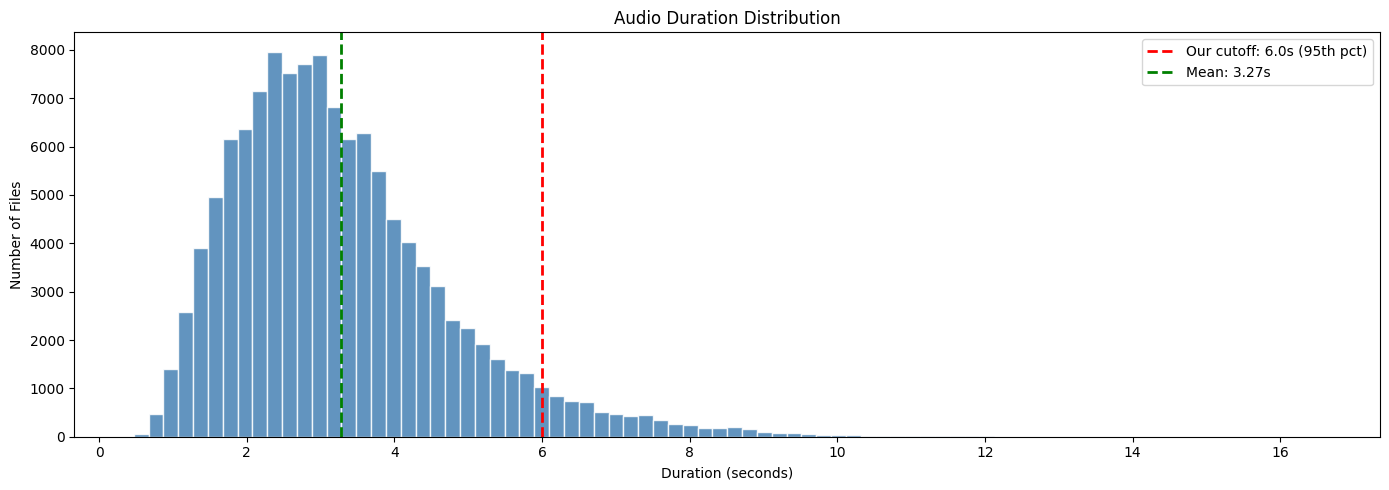

In [41]:
# Plot duration distribution
plt.figure(figsize=(14, 5))
plt.hist(all_durations, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(6.0, color="red", linestyle="--", linewidth=2, label="Our cutoff: 6.0s (95th pct)")
plt.axvline(all_durations.mean(), color="green", linestyle="--", linewidth=2,
            label=f"Mean: {all_durations.mean():.2f}s")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.title("Audio Duration Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# We choose 6 seconds (95th percentile)
# This means only ~5% of files get truncated
MAX_DURATION = 6
MAX_SAMPLES = TARGET_SR * MAX_DURATION  # 96000

truncated = np.sum(all_durations > MAX_DURATION)
print(f"MAX_DURATION = {MAX_DURATION}s ({MAX_SAMPLES} samples)")
print(f"Files truncated: {truncated} ({100*truncated/len(all_durations):.1f}%)")
print(f"Files padded:    {len(all_durations) - truncated} ({100*(1-truncated/len(all_durations)):.1f}%)")

MAX_DURATION = 6s (96000 samples)
Files truncated: 6762 (5.5%)
Files padded:    115537 (94.5%)


## 1.4 Preprocess All Audio Files

For each audio file:
- Convert to mono (single channel)
- Resample to 16kHz (what Wav2Vec2 expects)
- Pad short files with silence OR truncate long files to 6 seconds
- Save the preprocessed file
- Record the original length (needed for masks during training)

In [43]:
import soundfile as sf
import pandas as pd

def preprocess_one_file(input_path, output_path, max_samples=MAX_SAMPLES, target_sr=TARGET_SR):
    """
    Preprocess a single audio file.
    Returns metadata dict or None if failed.
    """
    try:
        # Load audio
        audio, sr = librosa.load(str(input_path), sr=None, mono=True)

        # Resample to 16kHz if needed
        if sr != target_sr:
            audio = librosa.resample(y=audio, orig_sr=sr, target_sr=target_sr)

        original_length = len(audio)

        # Pad or truncate to max_samples
        if original_length < max_samples:
            audio = np.pad(audio, (0, max_samples - original_length), mode="constant")
        else:
            audio = audio[:max_samples]
            original_length = max_samples

        # Save preprocessed audio
        output_path.parent.mkdir(parents=True, exist_ok=True)
        sf.write(str(output_path), audio, target_sr)

        return {
            "audio_id": input_path.stem,
            "original_length": original_length,
            "was_padded": original_length < max_samples,
            "was_truncated": original_length > max_samples,
            "status": "success"
        }
    except Exception as e:
        return {
            "audio_id": input_path.stem,
            "status": "failed",
            "error": str(e)
        }

In [44]:
# Process all splits
SPLIT_FOLDERS = {
    "train": ("ASVspoof2019_LA_train/flac", "train"),
    "dev": ("ASVspoof2019_LA_dev/flac", "dev"),
    "eval": ("ASVspoof2019_LA_eval/flac", "eval"),
}

all_metadata = []

for split_name, (folder, out_name) in SPLIT_FOLDERS.items():
    input_folder = INPUT_ROOT / folder
    output_folder = PREPROCESSED_DIR / out_name
    files = sorted(input_folder.glob("*.flac"))

    print(f"\nProcessing {split_name}: {len(files)} files")

    for f in tqdm(files, desc=split_name):
        output_path = output_folder / f"{f.stem}.flac"
        result = preprocess_one_file(f, output_path)
        result["split"] = split_name
        all_metadata.append(result)

# Save metadata
metadata_df = pd.DataFrame(all_metadata)
metadata_df.to_csv(PREPROCESSED_DIR / "metadata.csv", index=False)


Processing train: 25380 files


train: 100%|██████████| 25380/25380 [03:34<00:00, 118.17it/s]



Processing dev: 24986 files


dev: 100%|██████████| 24986/24986 [03:21<00:00, 124.26it/s]



Processing eval: 71933 files


eval: 100%|██████████| 71933/71933 [09:21<00:00, 128.12it/s]


In [45]:
# Summary
success = metadata_df[metadata_df["status"] == "success"]
failed = metadata_df[metadata_df["status"] == "failed"]

print(f"\nPreprocessing Complete!")
print(f"  Successful: {len(success)}")
print(f"  Failed:     {len(failed)}")
print(f"  Padded:     {success['was_padded'].sum()}")
print(f"  Truncated:  {success['was_truncated'].sum()}")

# Verify file counts
for split_name, (_, out_name) in SPLIT_FOLDERS.items():
    count = len(list((PREPROCESSED_DIR / out_name).glob("*.flac")))
    print(f"  {split_name}: {count} preprocessed files saved")


Preprocessing Complete!
  Successful: 122299
  Failed:     0
  Padded:     115537
  Truncated:  0
  train: 25380 preprocessed files saved
  dev: 24986 preprocessed files saved
  eval: 71933 preprocessed files saved


## 1.5 Copy Protocols to Preprocessed Directory

The protocol files tell us which audio is real (bonafide) and which is fake (spoof).
We copy them alongside the preprocessed audio for easy access.

In [46]:
import shutil

proto_dest = PREPROCESSED_DIR / "protocols"
proto_dest.mkdir(exist_ok=True)

for proto_file in PROTOCOL_DIR.glob("*.txt"):
    shutil.copy2(str(proto_file), str(proto_dest / proto_file.name))
    print(f"Copied: {proto_file.name}")

Copied: ASVspoof2019.LA.cm.dev.trl.txt
Copied: ASVspoof2019.LA.cm.eval.trl.txt
Copied: ASVspoof2019.LA.cm.train.trn.txt


## 1.6 Delete Raw Data to Free Space

The raw data takes ~18GB. Now that we have preprocessed files,
we don't need it anymore. This frees up Colab disk space.

In [ ]:
print(f"Disk usage BEFORE cleanup:")
!df -h /content | tail -1

print(f"\nDeleting raw data...")
!rm -rf /content/raw_data

print(f"\nDisk usage AFTER cleanup:")
!df -h /content | tail -1

In [47]:
# Verify preprocessed data is still there
print("Preprocessed data:")
!du -sh /content/preprocessed/*

print(f"\nTotal preprocessed:")
!du -sh /content/preprocessed

Preprocessed data:
1.5G	/content/preprocessed/dev
4.1G	/content/preprocessed/eval
5.1M	/content/preprocessed/metadata.csv
3.9M	/content/preprocessed/protocols
1.5G	/content/preprocessed/train

Total preprocessed:
6.9G	/content/preprocessed


## 1.7 Save Config

Save configuration so other notebooks use the same settings.

In [48]:
import json

config = {
    "TARGET_SR": TARGET_SR,
    "MAX_DURATION": MAX_DURATION,
    "MAX_SAMPLES": MAX_SAMPLES,
    "PREPROCESSED_DIR": str(PREPROCESSED_DIR),
    "total_files_processed": len(success),
}

# Save to preprocessed dir (local)
with open(PREPROCESSED_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

# Also save to Google Drive (persists between sessions)
with open("/content/drive/MyDrive/deepfake_project/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Config saved!")
print(json.dumps(config, indent=2))
print("\n✅ Notebook 1 complete. Proceed to Notebook 2.")

Config saved!
{
  "TARGET_SR": 16000,
  "MAX_DURATION": 6,
  "MAX_SAMPLES": 96000,
  "PREPROCESSED_DIR": "/content/preprocessed",
  "total_files_processed": 122299
}

✅ Notebook 1 complete. Proceed to Notebook 2.


# Data Augmentation

In [50]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [51]:
# Configuration
PREPROCESSED_DIR = Path("/content/preprocessed")
TARGET_SR = 16000
MAX_DURATION = 6
MAX_SAMPLES = TARGET_SR * MAX_DURATION  # 96000
BATCH_SIZE = 8

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Verify data exists
for split in ["train", "dev", "eval"]:
    folder = PREPROCESSED_DIR / split
    count = len(list(folder.glob("*.flac"))) if folder.exists() else 0
    print(f"{split}: {count} files")

assert (PREPROCESSED_DIR / "metadata.csv").exists(), "metadata.csv not found! Run Notebook 1 first."
metadata = pd.read_csv(PREPROCESSED_DIR / "metadata.csv")
print(f"\nMetadata: {len(metadata)} entries")

train: 25380 files
dev: 24986 files
eval: 71933 files

Metadata: 122299 entries


## 2.2 Load Protocol Files

Protocol files are like a label sheet — they tell us which audio
is real (bonafide) and which is fake (spoof), and what attack
type was used to create the fake audio.

In [52]:
def load_protocol(protocol_path):
    """Load ASVspoof protocol file and add integer labels."""
    df = pd.read_csv(
        protocol_path, sep=" ", header=None,
        names=["speaker_id", "audio_id", "system_id", "attack_type", "label"]
    )
    # bonafide = 0 (real), spoof = 1 (fake)
    df["label_int"] = (df["label"] == "spoof").astype(int)
    return df

PROTOCOL_DIR = PREPROCESSED_DIR / "protocols"
train_protocol = load_protocol(PROTOCOL_DIR / "ASVspoof2019.LA.cm.train.trn.txt")
dev_protocol = load_protocol(PROTOCOL_DIR / "ASVspoof2019.LA.cm.dev.trl.txt")
eval_protocol = load_protocol(PROTOCOL_DIR / "ASVspoof2019.LA.cm.eval.trl.txt")

print(f"Train: {len(train_protocol)} samples")
print(f"Dev:   {len(dev_protocol)} samples")
print(f"Eval:  {len(eval_protocol)} samples")
print(f"\nTrain labels:\n{train_protocol['label'].value_counts()}")

Train: 25380 samples
Dev:   24844 samples
Eval:  71237 samples

Train labels:
label
spoof       22800
bonafide     2580
Name: count, dtype: int64


## 2.3 RawBoost Augmentation

**What is RawBoost?**
RawBoost simulates real-world audio distortions. Imagine someone
calling you on a bad phone connection — the audio gets distorted
by the channel. RawBoost does this artificially so the model
learns to detect deepfakes even in messy audio conditions.

Two types:
- **Type 1 (Convolutive)**: Simulates channel effects (like different microphones)
- **Type 2 (Impulsive noise)**: Adds noise that depends on the audio signal

In [53]:
def rawboost_convolutive(audio_np, sr=TARGET_SR):
    """
    Simulates channel effects by applying random notch filters.
    Like recording through different microphones or phone lines.
    """
    n_notch = np.random.randint(1, 5)
    n = len(audio_np)
    spectrum = np.fft.rfft(audio_np)
    freqs = np.fft.rfftfreq(n, d=1.0 / sr)

    for _ in range(n_notch):
        freq = np.random.uniform(100, sr // 2 - 100)
        bw = np.random.uniform(50, 300)
        mask = 1.0 - np.exp(-0.5 * ((freqs - freq) / (bw / 2 + 1e-8)) ** 2)
        spectrum = spectrum * mask

    return np.fft.irfft(spectrum, n=n).astype(np.float32)


def rawboost_impulsive_noise(audio_np, sr=TARGET_SR):
    """
    Adds signal-dependent noise — louder parts get more noise,
    quiet parts get less. More realistic than uniform noise.
    """
    noise_level = np.random.uniform(0.001, 0.01)
    noise = noise_level * np.random.randn(len(audio_np)) * np.abs(audio_np)
    return (audio_np + noise).astype(np.float32)


def rawboost_augment(audio_np):
    """Apply both RawBoost types with 50% chance each."""
    audio_np = audio_np.copy()
    if np.random.rand() < 0.5:
        audio_np = rawboost_convolutive(audio_np)
    if np.random.rand() < 0.5:
        audio_np = rawboost_impulsive_noise(audio_np)
    return audio_np

## 2.4 Codec Augmentation

**What is Codec Augmentation?**
When you send audio over WhatsApp, Zoom, or a phone call,
it gets compressed. This compression changes the audio slightly.
Codec augmentation simulates this so the model can handle
compressed audio from real-world sources.

In [54]:
def codec_augment(audio_np, sr=TARGET_SR):
    """Simulate audio compression (like WhatsApp/Zoom calls)."""
    audio_t = torch.from_numpy(audio_np).unsqueeze(0).float()

    if np.random.rand() < 0.5:
        # mu-law: simulates telephone compression
        q = torchaudio.functional.mu_law_encoding(audio_t, 256)
        audio_t = torchaudio.functional.mu_law_decoding(q, 256)
    else:
        # Downsample to 8kHz and back: loses high frequencies (telephone bandwidth)
        audio_t = torchaudio.transforms.Resample(sr, 8000)(audio_t)
        audio_t = torchaudio.transforms.Resample(8000, sr)(audio_t)

    return audio_t.squeeze(0).numpy()


def apply_augmentation(audio_tensor):
    """
    Full augmentation pipeline.
    Called on every training sample, every epoch — always random.
    """
    audio_np = audio_tensor.numpy().copy()

    # RawBoost: 70% chance
    if np.random.rand() < 0.7:
        audio_np = rawboost_augment(audio_np)

    # Codec: 30% chance
    if np.random.rand() < 0.3:
        audio_np = codec_augment(audio_np)

    return torch.from_numpy(audio_np).float()

## 2.5 Visualize Augmentation

Let's see what augmentation actually does to an audio file.
The same audio looks different each time because augmentation is random.

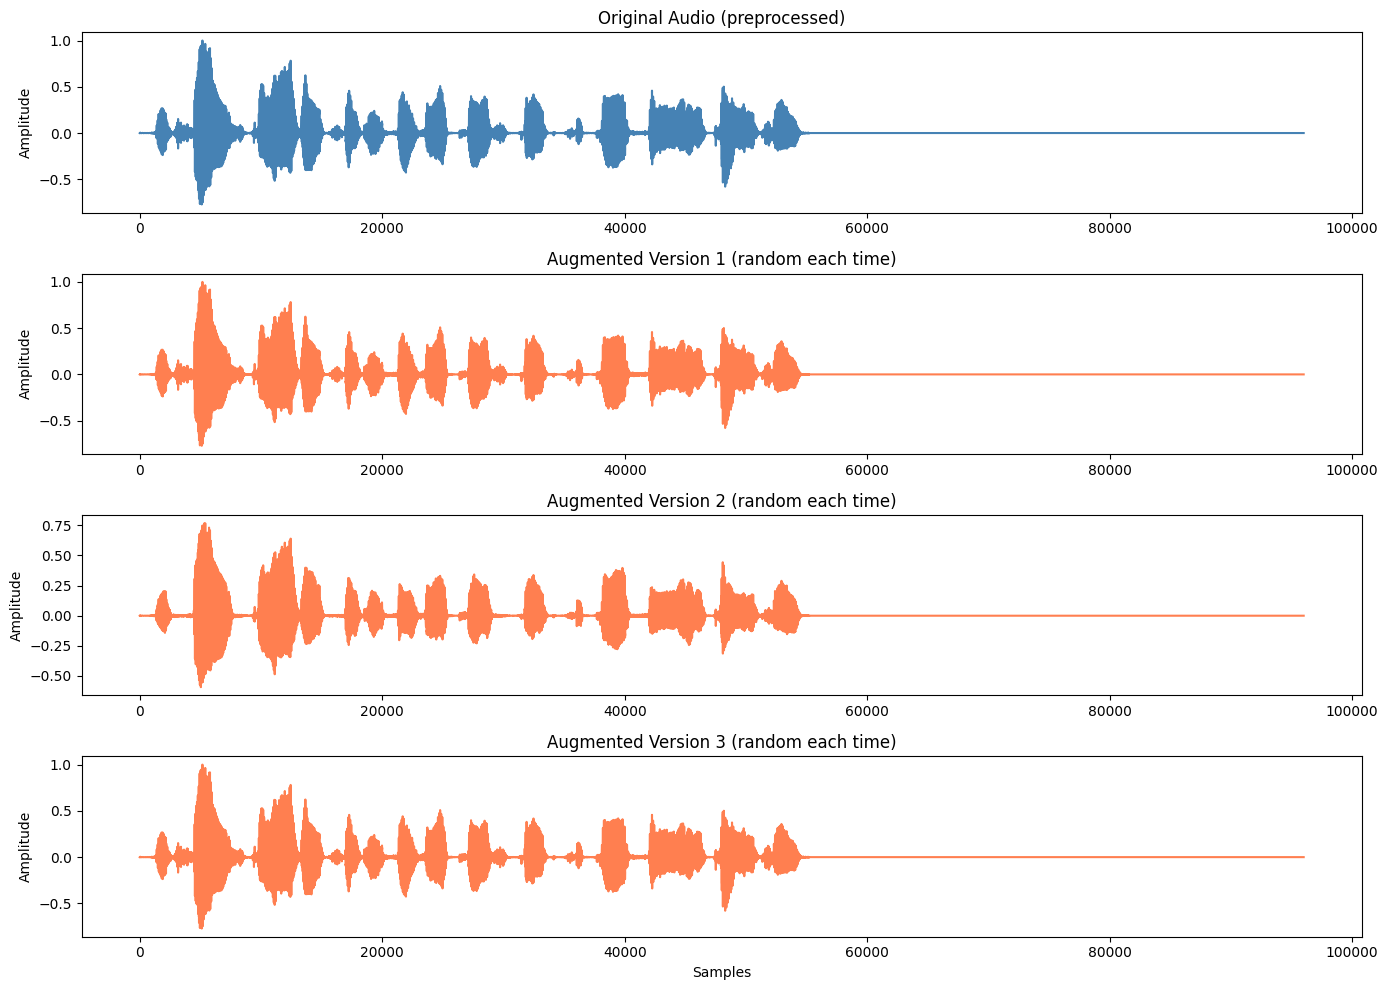

In [55]:
sample_file = list((PREPROCESSED_DIR / "train").glob("*.flac"))[0]
sample_audio, sr = torchaudio.load(str(sample_file))
sample_audio = sample_audio.squeeze(0)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(sample_audio.numpy(), color="steelblue")
axes[0].set_title("Original Audio (preprocessed)")
axes[0].set_ylabel("Amplitude")

for i in range(1, 4):
    augmented = apply_augmentation(sample_audio)
    axes[i].plot(augmented.numpy(), color="coral")
    axes[i].set_title(f"Augmented Version {i} (random each time)")
    axes[i].set_ylabel("Amplitude")

axes[-1].set_xlabel("Samples")
plt.tight_layout()
plt.show()

## 2.6 PyTorch Dataset

**What is a Dataset?**
A Dataset is like a smart filing cabinet. When the model asks for
sample #5000, the Dataset knows how to:
1. Find the right audio file
2. Apply augmentation (if training)
3. Normalize the volume
4. Create the attention mask
5. Return everything in a neat package

In [56]:
class ASVspoofDataset(Dataset):
    def __init__(self, protocol_df, audio_dir, metadata_df, is_train=False):
        """
        Args:
            protocol_df: DataFrame with audio_id, label, attack_type
            audio_dir: Path to preprocessed audio files
            metadata_df: DataFrame with original_length for each audio
            is_train: If True, apply augmentation
        """
        self.protocol = protocol_df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.is_train = is_train

        # Build lookup: audio_id -> original_length (for creating masks)
        self.length_lookup = {}
        for _, row in metadata_df.iterrows():
            if row["status"] == "success":
                self.length_lookup[row["audio_id"]] = int(row["original_length"])

    def __len__(self):
        return len(self.protocol)

    def __getitem__(self, idx):
        row = self.protocol.iloc[idx]
        audio_id = row["audio_id"]

        # 1. Load preprocessed audio
        file_path = self.audio_dir / f"{audio_id}.flac"
        audio, sr = torchaudio.load(str(file_path))
        audio = audio.squeeze(0)  # [96000]

        # 2. Augmentation (training only, random each time)
        if self.is_train:
            audio = apply_augmentation(audio)

        # 3. Peak normalization (after augmentation)
        max_val = torch.max(torch.abs(audio))
        if max_val > 0:
            audio = audio / max_val

        # 4. Create attention mask from original length
        original_length = self.length_lookup.get(audio_id, MAX_SAMPLES)
        mask = torch.zeros(MAX_SAMPLES)
        mask[:original_length] = 1.0

        return {
            "audio": audio,                                          # [96000]
            "mask": mask,                                             # [96000]
            "label": torch.tensor(row["label_int"], dtype=torch.long),  # 0 or 1
            "audio_id": audio_id,
            "attack_type": row["attack_type"],
        }

## 2.7 Create & Test DataLoaders

In [57]:
# Create datasets
train_dataset = ASVspoofDataset(
    train_protocol, PREPROCESSED_DIR / "train", metadata, is_train=True
)
dev_dataset = ASVspoofDataset(
    dev_protocol, PREPROCESSED_DIR / "dev", metadata, is_train=False
)
eval_dataset = ASVspoofDataset(
    eval_protocol, PREPROCESSED_DIR / "eval", metadata, is_train=False
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Dev:   {len(dev_dataset)} samples, {len(dev_loader)} batches")
print(f"Eval:  {len(eval_dataset)} samples, {len(eval_loader)} batches")

Train: 25380 samples, 3173 batches
Dev:   24844 samples, 3106 batches
Eval:  71237 samples, 8905 batches


In [58]:
# Test one batch
batch = next(iter(train_loader))
print("Batch contents:")
print(f"  audio shape:   {batch['audio'].shape}")       # [8, 96000]
print(f"  mask shape:    {batch['mask'].shape}")         # [8, 96000]
print(f"  labels:        {batch['label'].tolist()}")
print(f"  audio_ids:     {batch['audio_id'][:3]}...")
print(f"  attack_types:  {batch['attack_type'][:3]}...")
print(f"  audio max val: {batch['audio'].abs().max():.4f} (should be ~1.0)")

Batch contents:
  audio shape:   torch.Size([8, 96000])
  mask shape:    torch.Size([8, 96000])
  labels:        [1, 1, 1, 1, 1, 1, 1, 1]
  audio_ids:     ['LA_T_5061576', 'LA_T_4460204', 'LA_T_4114067']...
  attack_types:  ['A03', 'A01', 'A03']...
  audio max val: 1.0000 (should be ~1.0)


In [59]:
# Verify augmentation randomness
a1 = train_dataset[0]["audio"]
a2 = train_dataset[0]["audio"]
diff = torch.abs(a1 - a2).mean().item()
print(f"Same sample loaded twice — difference: {diff:.6f}")
print(f"Augmentation working: {'YES' if diff > 1e-6 else 'NO — check augmentation code!'}")

Same sample loaded twice — difference: 0.000095
Augmentation working: YES


# Teacher Model Training

**What this does (in simple terms):**

This is where the "smart" model (teacher) learns to tell real audio
from fake audio. It uses two parts:

- **Wav2Vec2-XLSR** (front-end): A huge pretrained model that "listens"
  to raw audio and extracts meaningful patterns — like how your brain
  processes sound into recognizable features.

- **AASIST** (back-end): A graph attention network that looks at those
  patterns from both the frequency angle (pitch, tone) and time angle
  (rhythm, pauses) to find spoofing clues. Then it decides: real or fake.

The teacher is the big, powerful model. Later in Notebook 4, it will
teach a smaller, faster model (student) what it learned.

**Checkpoint strategy:** The model is saved after every epoch to Google
Drive. If Colab disconnects, you can restart and it will pick up
exactly where it left off — no lost training.

**Run on Colab Pro with GPU. Training takes ~8-15 hours.**

In [60]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
!pip install transformers -q

In [62]:
import os, json, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import torchaudio
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Model
from sklearn.metrics import accuracy_score, roc_curve
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [63]:
# ============================================================
# CONFIGURATION
# ============================================================
PREPROCESSED_DIR = Path("/content/preprocessed")
CHECKPOINT_DIR = Path("/content/drive/MyDrive/deepfake_project/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16000
MAX_DURATION = 6
MAX_SAMPLES = TARGET_SR * MAX_DURATION  # 96000

BATCH_SIZE = 8
NUM_EPOCHS = 10
LEARNING_RATE_W2V = 1e-5       # Low LR for pretrained weights
LEARNING_RATE_BACKEND = 1e-4    # Higher LR for new backend
WEIGHT_DECAY = 1e-4

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device: cuda
GPU: Tesla T4


In [64]:
# Verify preprocessed data exists
assert PREPROCESSED_DIR.exists(), "Preprocessed data not found! Run Notebook 1 first."
for split in ["train", "dev"]:
    count = len(list((PREPROCESSED_DIR / split).glob("*.flac")))
    print(f"{split}: {count} files")

train: 25380 files
dev: 24986 files


## 3.2 Load Protocols & Build Dataset

Same Dataset code from Notebook 2, included here so this
notebook is self-contained.

In [65]:
def load_protocol(path):
    df = pd.read_csv(path, sep=" ", header=None,
                     names=["speaker_id", "audio_id", "system_id", "attack_type", "label"])
    df["label_int"] = (df["label"] == "spoof").astype(int)
    return df

PROTOCOL_DIR = PREPROCESSED_DIR / "protocols"
train_protocol = load_protocol(PROTOCOL_DIR / "ASVspoof2019.LA.cm.train.trn.txt")
dev_protocol = load_protocol(PROTOCOL_DIR / "ASVspoof2019.LA.cm.dev.trl.txt")
metadata = pd.read_csv(PREPROCESSED_DIR / "metadata.csv")

print(f"Train: {len(train_protocol)} | Dev: {len(dev_protocol)}")

Train: 25380 | Dev: 24844


In [66]:
# --- Augmentation functions ---
def rawboost_convolutive(audio_np, sr=TARGET_SR):
    n = len(audio_np); spectrum = np.fft.rfft(audio_np)
    freqs = np.fft.rfftfreq(n, d=1.0/sr)
    for _ in range(np.random.randint(1, 5)):
        f = np.random.uniform(100, sr//2-100); bw = np.random.uniform(50, 300)
        spectrum *= 1.0 - np.exp(-0.5*((freqs-f)/(bw/2+1e-8))**2)
    return np.fft.irfft(spectrum, n=n).astype(np.float32)

def rawboost_impulsive(audio_np):
    nl = np.random.uniform(0.001, 0.01)
    return (audio_np + nl*np.random.randn(len(audio_np))*np.abs(audio_np)).astype(np.float32)

def rawboost_augment(a):
    a = a.copy()
    if np.random.rand() < 0.5: a = rawboost_convolutive(a)
    if np.random.rand() < 0.5: a = rawboost_impulsive(a)
    return a

def codec_augment(a, sr=TARGET_SR):
    t = torch.from_numpy(a).unsqueeze(0).float()
    if np.random.rand() < 0.5:
        t = torchaudio.functional.mu_law_decoding(
            torchaudio.functional.mu_law_encoding(t, 256), 256)
    else:
        t = torchaudio.transforms.Resample(sr, 8000)(t)
        t = torchaudio.transforms.Resample(8000, sr)(t)
    return t.squeeze(0).numpy()

def apply_augmentation(audio_tensor):
    a = audio_tensor.numpy().copy()
    if np.random.rand() < 0.7: a = rawboost_augment(a)
    if np.random.rand() < 0.3: a = codec_augment(a)
    return torch.from_numpy(a).float()

In [67]:
# --- Dataset class ---
class ASVspoofDataset(Dataset):
    def __init__(self, protocol_df, audio_dir, metadata_df, is_train=False):
        self.protocol = protocol_df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.is_train = is_train
        self.length_lookup = {}
        for _, row in metadata_df.iterrows():
            if row.get("status") == "success":
                self.length_lookup[row["audio_id"]] = int(row["original_length"])

    def __len__(self): return len(self.protocol)

    def __getitem__(self, idx):
        row = self.protocol.iloc[idx]
        audio, _ = torchaudio.load(str(self.audio_dir / f"{row['audio_id']}.flac"))
        audio = audio.squeeze(0)
        if self.is_train:
            audio = apply_augmentation(audio)
        mx = torch.max(torch.abs(audio))
        if mx > 0: audio = audio / mx
        orig_len = self.length_lookup.get(row["audio_id"], MAX_SAMPLES)
        mask = torch.zeros(MAX_SAMPLES); mask[:orig_len] = 1.0
        return {"audio": audio, "mask": mask,
                "label": torch.tensor(row["label_int"], dtype=torch.long),
                "audio_id": row["audio_id"], "attack_type": row["attack_type"]}

In [68]:
train_dataset = ASVspoofDataset(train_protocol, PREPROCESSED_DIR/"train", metadata, is_train=True)
dev_dataset = ASVspoofDataset(dev_protocol, PREPROCESSED_DIR/"dev", metadata, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Train: {len(train_loader)} batches | Dev: {len(dev_loader)} batches")

Train: 3173 batches | Dev: 3106 batches


## 3.3 Model Architecture

In [69]:
class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.a_src = nn.Linear(out_dim, 1, bias=False)
        self.a_dst = nn.Linear(out_dim, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        h = self.W(x)
        attn = self.leaky_relu(self.a_src(h) + self.a_dst(h).transpose(-2, -1))
        return torch.bmm(self.dropout(F.softmax(attn, dim=-1)), h)

class MultiHeadGraphAttention(nn.Module):
    def __init__(self, in_dim, out_dim, n_heads=2, dropout=0.1):
        super().__init__()
        self.heads = nn.ModuleList([GraphAttentionLayer(in_dim, out_dim, dropout) for _ in range(n_heads)])
        self.norm = nn.LayerNorm(out_dim * n_heads)
    def forward(self, x):
        return self.norm(torch.cat([h(x) for h in self.heads], dim=-1))

class AASSISTBackend(nn.Module):
    """Full AASIST backend for teacher (hidden_dim=160)."""
    def __init__(self, input_dim=1024, hidden_dim=160, n_heads=2, dropout=0.1):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.GELU(),
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout))
        self.spectral_gat = MultiHeadGraphAttention(hidden_dim, hidden_dim, n_heads, dropout)
        self.spectral_pool = nn.AdaptiveAvgPool1d(1)
        self.temporal_gat = MultiHeadGraphAttention(hidden_dim, hidden_dim, n_heads, dropout)
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        cd = hidden_dim * n_heads * 2
        self.hetero_attention = nn.Sequential(
            nn.Linear(cd, hidden_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, 2))

    def forward(self, features):
        x = self.projection(features)
        sp = self.spectral_pool(self.spectral_gat(x).transpose(1, 2)).squeeze(-1)
        tp = self.temporal_pool(self.temporal_gat(x).transpose(1, 2)).squeeze(-1)
        return self.classifier(self.hetero_attention(torch.cat([sp, tp], dim=-1)))

class TeacherModel(nn.Module):
    def __init__(self, w2v_name="facebook/wav2vec2-xls-r-300m", hidden_dim=160):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(w2v_name)
        self.wav2vec2.feature_extractor._freeze_parameters()
        self.backend = AASSISTBackend(
            input_dim=self.wav2vec2.config.hidden_size, hidden_dim=hidden_dim)

    def forward(self, audio, mask=None):
        if mask is not None:
            mask = mask.long()
        features = self.wav2vec2(audio, attention_mask=mask).last_hidden_state
        return self.backend(features)

    def get_param_groups(self):
        return [
            {"params": self.wav2vec2.parameters(), "lr": LEARNING_RATE_W2V},
            {"params": self.backend.parameters(), "lr": LEARNING_RATE_BACKEND},
        ]

In [70]:
def count_params(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

print("Loading Wav2Vec2-XLSR (takes 1-2 min)...")
teacher = TeacherModel().to(DEVICE)
print(f"Total params:     {count_params(teacher, False):,}")
print(f"Trainable params: {count_params(teacher, True):,}")

# Quick test
with torch.no_grad():
    out = teacher(torch.randn(2, MAX_SAMPLES).to(DEVICE),
                  torch.ones(2, MAX_SAMPLES).to(DEVICE))
    print(f"Output shape: {out.shape}")  # [2, 2]
print("Model ready!")

Loading Wav2Vec2-XLSR (takes 1-2 min)...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Total params:     315,846,754
Trainable params: 311,636,578
Output shape: torch.Size([2, 2])
Model ready!


## 3.4 Loss Function & Metrics

In [71]:
class OCSoftmax(nn.Module):
    """
    OC-Softmax: adds margins to push bonafide and spoof predictions apart.
    Think of it as making the model more confident in its decisions.
    """
    def __init__(self, m_real=0.9, m_fake=0.2, alpha=20.0):
        super().__init__()
        self.m_real = m_real; self.m_fake = m_fake; self.alpha = alpha

    def forward(self, logits, labels):
        real_mask = (labels == 0).float()
        spoof_mask = (labels == 1).float()
        mod = logits.clone()
        mod[:, 0] = logits[:, 0] - self.m_real * real_mask
        mod[:, 1] = logits[:, 1] - self.m_fake * spoof_mask
        return F.cross_entropy(self.alpha * mod, labels)

def compute_eer(labels, scores):
    """Equal Error Rate: the point where false accepts = false rejects."""
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2, thresholds[idx]

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0; all_scores, all_preds, all_labels = [], [], []
    for batch in tqdm(dataloader, desc="Evaluating"):
        audio = batch["audio"].to(device); mask = batch["mask"].to(device)
        labels = batch["label"].to(device)
        logits = model(audio, mask)
        total_loss += criterion(logits, labels).item()
        all_scores.extend(F.softmax(logits, dim=-1)[:, 1].cpu().numpy())
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    labels_arr = np.array(all_labels); scores_arr = np.array(all_scores)
    eer, _ = compute_eer(labels_arr, scores_arr)
    return {"loss": total_loss/len(dataloader), "eer": eer,
            "accuracy": accuracy_score(labels_arr, np.array(all_preds))}

## 3.5 Training Loop with Checkpoint Resume

**Checkpoint strategy:**
- After every epoch, the full state is saved to Google Drive
- If Colab disconnects, just run this notebook again
- It automatically detects the checkpoint and continues training

In [72]:
criterion = OCSoftmax().to(DEVICE)
optimizer = torch.optim.AdamW(teacher.get_param_groups(), weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [73]:
# --- Check for existing checkpoint to resume from ---
TEACHER_CKPT_PATH = CHECKPOINT_DIR / "teacher_latest.pt"
TEACHER_BEST_PATH = CHECKPOINT_DIR / "teacher_best.pt"

start_epoch = 1
best_dev_eer = float("inf")
history = {"train_loss": [], "train_acc": [], "dev_eer": [], "dev_loss": []}

if TEACHER_CKPT_PATH.exists():
    print("Found existing checkpoint! Resuming training...")
    ckpt = torch.load(str(TEACHER_CKPT_PATH), map_location=DEVICE)
    teacher.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_dev_eer = ckpt["best_dev_eer"]
    history = ckpt["history"]
    print(f"Resuming from epoch {start_epoch} (best EER so far: {best_dev_eer*100:.2f}%)")
else:
    print("No checkpoint found. Starting fresh training.")

No checkpoint found. Starting fresh training.


In [74]:
print("=" * 60)
print(f"TEACHER TRAINING: Epochs {start_epoch} to {NUM_EPOCHS}")
print("=" * 60)

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\n{'='*40} Epoch {epoch}/{NUM_EPOCHS} {'='*40}")

    # --- Train one epoch ---
    teacher.train()
    epoch_loss = 0; epoch_preds = []; epoch_labels = []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for batch in pbar:
        audio = batch["audio"].to(DEVICE)
        mask = batch["mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        logits = teacher(audio, mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(teacher.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        epoch_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = epoch_loss / len(train_loader)
    train_acc = accuracy_score(epoch_labels, epoch_preds)

    # --- Validate ---
    dev_res = evaluate(teacher, dev_loader, criterion, DEVICE)
    scheduler.step()

    # --- Log ---
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["dev_eer"].append(dev_res["eer"])
    history["dev_loss"].append(dev_res["loss"])

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Dev Loss:   {dev_res['loss']:.4f} | Dev EER: {dev_res['eer']*100:.2f}%")

    # --- Save best model ---
    if dev_res["eer"] < best_dev_eer:
        best_dev_eer = dev_res["eer"]
        torch.save({"epoch": epoch, "model_state_dict": teacher.state_dict(),
                     "dev_eer": best_dev_eer},
                   str(TEACHER_BEST_PATH))
        print(f"  ★ New best model saved! (EER: {best_dev_eer*100:.2f}%)")

    # --- Save checkpoint for resume (every epoch) ---
    torch.save({
        "epoch": epoch,
        "model_state_dict": teacher.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_dev_eer": best_dev_eer,
        "history": history,
    }, str(TEACHER_CKPT_PATH))
    print(f"  Checkpoint saved to Google Drive (epoch {epoch})")

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE! Best Dev EER: {best_dev_eer*100:.2f}%")
print(f"{'='*60}")

TEACHER TRAINING: Epochs 1 to 10

======================================== Epoch 1/10 ========================================


Evaluating: 100%|██████████| 3106/3106 [32:38<00:00,  1.59it/s]


  Train Loss: 0.9735 | Train Acc: 0.9645
  Dev Loss:   2.7883 | Dev EER: 0.24%
  ★ New best model saved! (EER: 0.24%)
  Checkpoint saved to Google Drive (epoch 1)

======================================== Epoch 2/10 ========================================


Evaluating: 100%|██████████| 3106/3106 [32:34<00:00,  1.59it/s]


  Train Loss: 0.2506 | Train Acc: 0.9918
  Dev Loss:   1.0024 | Dev EER: 0.15%
  ★ New best model saved! (EER: 0.15%)
  Checkpoint saved to Google Drive (epoch 2)

======================================== Epoch 3/10 ========================================


...

  Train Loss: 0.0993 | Train Acc: 0.9965
  Dev Loss:   0.1275 | Dev EER: 0.03%
  Checkpoint saved to Google Drive (epoch 4)

======================================== Epoch 5/10 ========================================


Evaluating: 100%|██████████| 3106/3106 [32:32<00:00,  1.59it/s]


  Train Loss: 0.0573 | Train Acc: 0.9983
  Dev Loss:   0.0485 | Dev EER: 0.04%
  Checkpoint saved to Google Drive (epoch 5)

======================================== Epoch 6/10 ========================================


Epoch 6 [Train]:   3%|▎         | 96/3173 [02:34<1:22:27,  1.61s/it, loss=0.0000]


KeyboardInterrupt: 

## 3.6 Training Plots

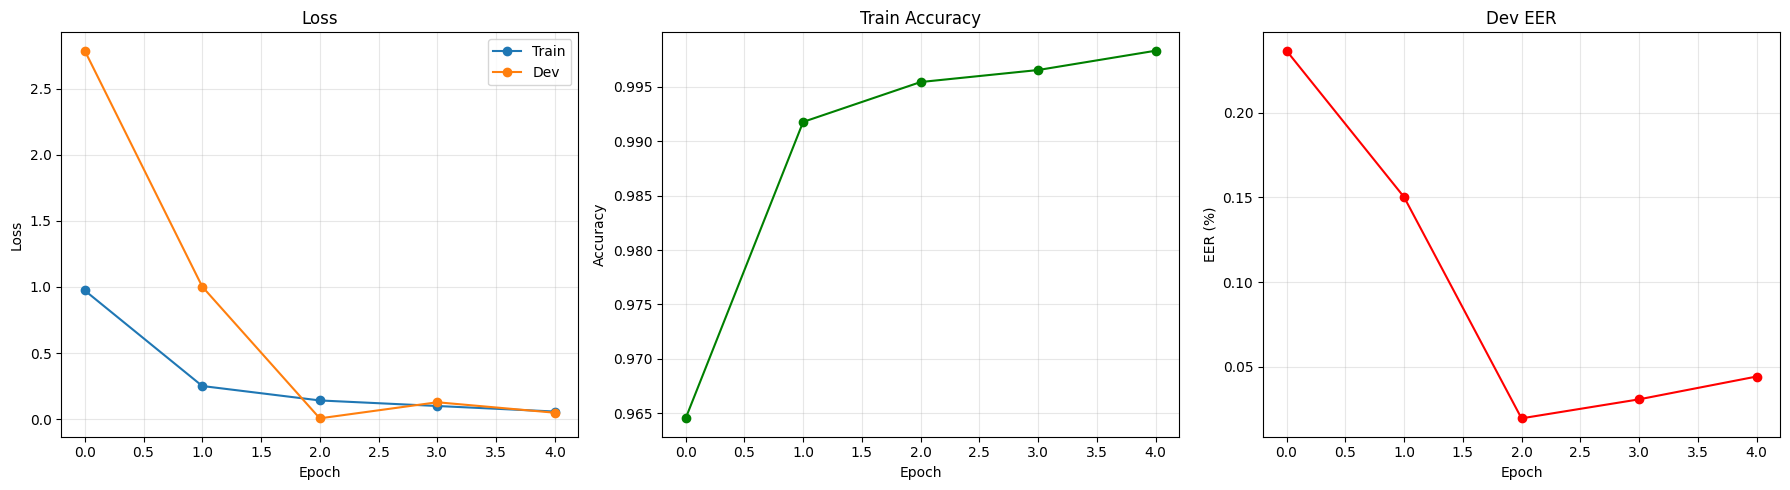


✅ Notebook 3 complete. Proceed to Notebook 4: Knowledge Distillation.


In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], "o-", label="Train")
axes[0].plot(history["dev_loss"], "o-", label="Dev")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], "o-", color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Train Accuracy"); axes[1].grid(True, alpha=0.3)

axes[2].plot([e*100 for e in history["dev_eer"]], "o-", color="red")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("EER (%)")
axes[2].set_title("Dev EER"); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / "teacher_training_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Notebook 3 complete. Proceed to Notebook 4: Knowledge Distillation.")

## 4.1 Setup

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
import os, json, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import torchaudio
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Model
from sklearn.metrics import accuracy_score, roc_curve
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [78]:
PREPROCESSED_DIR = Path("/content/preprocessed")
CHECKPOINT_DIR = Path("/content/drive/MyDrive/deepfake_project/checkpoints")

TARGET_SR = 16000; MAX_DURATION = 6; MAX_SAMPLES = TARGET_SR * MAX_DURATION
BATCH_SIZE = 8; NUM_EPOCHS = 10
LEARNING_RATE_BACKEND = 1e-4; WEIGHT_DECAY = 1e-4

# Knowledge distillation settings
KD_TEMPERATURE = 3.0   # Higher = softer probability distribution
KD_ALPHA = 0.5          # 0.5 = equal weight hard loss and soft loss

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [79]:
# Verify data and teacher checkpoint exist
assert PREPROCESSED_DIR.exists(), "Preprocessed data not found! Run Notebook 1 first."
assert (CHECKPOINT_DIR / "teacher_best.pt").exists(), "Teacher checkpoint not found! Run Notebook 3 first."
print("Preprocessed data: OK")
print("Teacher checkpoint: OK")

Preprocessed data: OK
Teacher checkpoint: OK


## 4.2 Load Data

In [80]:
def load_protocol(path):
    df = pd.read_csv(path, sep=" ", header=None,
                     names=["speaker_id", "audio_id", "system_id", "attack_type", "label"])
    df["label_int"] = (df["label"] == "spoof").astype(int)
    return df

PROTOCOL_DIR = PREPROCESSED_DIR / "protocols"
train_protocol = load_protocol(PROTOCOL_DIR / "ASVspoof2019.LA.cm.train.trn.txt")
dev_protocol = load_protocol(PROTOCOL_DIR / "ASVspoof2019.LA.cm.dev.trl.txt")
metadata = pd.read_csv(PREPROCESSED_DIR / "metadata.csv")
print(f"Train: {len(train_protocol)} | Dev: {len(dev_protocol)}")

Train: 25380 | Dev: 24844


In [81]:
# --- Augmentation (same as Notebook 3) ---
def rawboost_convolutive(a, sr=TARGET_SR):
    n = len(a); s = np.fft.rfft(a); fr = np.fft.rfftfreq(n, d=1.0/sr)
    for _ in range(np.random.randint(1,5)):
        f=np.random.uniform(100,sr//2-100); bw=np.random.uniform(50,300)
        s *= 1.0 - np.exp(-0.5*((fr-f)/(bw/2+1e-8))**2)
    return np.fft.irfft(s, n=n).astype(np.float32)

def rawboost_impulsive(a):
    nl=np.random.uniform(0.001,0.01)
    return (a + nl*np.random.randn(len(a))*np.abs(a)).astype(np.float32)

def rawboost_augment(a):
    a=a.copy()
    if np.random.rand()<0.5: a=rawboost_convolutive(a)
    if np.random.rand()<0.5: a=rawboost_impulsive(a)
    return a

def codec_augment(a, sr=TARGET_SR):
    t=torch.from_numpy(a).unsqueeze(0).float()
    if np.random.rand()<0.5:
        t=torchaudio.functional.mu_law_decoding(torchaudio.functional.mu_law_encoding(t,256),256)
    else:
        t=torchaudio.transforms.Resample(sr,8000)(t); t=torchaudio.transforms.Resample(8000,sr)(t)
    return t.squeeze(0).numpy()

def apply_augmentation(audio_tensor):
    a=audio_tensor.numpy().copy()
    if np.random.rand()<0.7: a=rawboost_augment(a)
    if np.random.rand()<0.3: a=codec_augment(a)
    return torch.from_numpy(a).float()

In [82]:
# --- Standard dataset (for generating soft predictions — no augmentation) ---
class ASVspoofDataset(Dataset):
    def __init__(self, protocol_df, audio_dir, metadata_df, is_train=False):
        self.protocol = protocol_df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.is_train = is_train
        self.length_lookup = {}
        for _, r in metadata_df.iterrows():
            if r.get("status") == "success":
                self.length_lookup[r["audio_id"]] = int(r["original_length"])
    def __len__(self): return len(self.protocol)
    def __getitem__(self, idx):
        row = self.protocol.iloc[idx]
        audio, _ = torchaudio.load(str(self.audio_dir / f"{row['audio_id']}.flac"))
        audio = audio.squeeze(0)
        if self.is_train: audio = apply_augmentation(audio)
        mx = torch.max(torch.abs(audio))
        if mx > 0: audio = audio / mx
        ol = self.length_lookup.get(row["audio_id"], MAX_SAMPLES)
        mask = torch.zeros(MAX_SAMPLES); mask[:ol] = 1.0
        return {"audio": audio, "mask": mask,
                "label": torch.tensor(row["label_int"], dtype=torch.long),
                "audio_id": row["audio_id"], "attack_type": row["attack_type"]}

## 4.3 Load Teacher Model & Generate Soft Predictions

In [83]:
# --- Teacher architecture (must match Notebook 3 exactly) ---
class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.a_src = nn.Linear(out_dim, 1, bias=False)
        self.a_dst = nn.Linear(out_dim, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        h = self.W(x)
        attn = self.leaky_relu(self.a_src(h) + self.a_dst(h).transpose(-2,-1))
        return torch.bmm(self.dropout(F.softmax(attn, dim=-1)), h)

class MultiHeadGraphAttention(nn.Module):
    def __init__(self, in_dim, out_dim, n_heads=2, dropout=0.1):
        super().__init__()
        self.heads = nn.ModuleList([GraphAttentionLayer(in_dim, out_dim, dropout) for _ in range(n_heads)])
        self.norm = nn.LayerNorm(out_dim * n_heads)
    def forward(self, x):
        return self.norm(torch.cat([h(x) for h in self.heads], dim=-1))

class AASSISTBackend(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=160, n_heads=2, dropout=0.1):
        super().__init__()
        self.projection = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.GELU(),
                                         nn.LayerNorm(hidden_dim), nn.Dropout(dropout))
        self.spectral_gat = MultiHeadGraphAttention(hidden_dim, hidden_dim, n_heads, dropout)
        self.spectral_pool = nn.AdaptiveAvgPool1d(1)
        self.temporal_gat = MultiHeadGraphAttention(hidden_dim, hidden_dim, n_heads, dropout)
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        cd = hidden_dim * n_heads * 2
        self.hetero_attention = nn.Sequential(nn.Linear(cd, hidden_dim), nn.GELU(),
                                               nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.classifier = nn.Sequential(nn.Linear(hidden_dim, 64), nn.GELU(),
                                         nn.Dropout(dropout), nn.Linear(64, 2))
    def forward(self, f):
        x = self.projection(f)
        sp = self.spectral_pool(self.spectral_gat(x).transpose(1,2)).squeeze(-1)
        tp = self.temporal_pool(self.temporal_gat(x).transpose(1,2)).squeeze(-1)
        return self.classifier(self.hetero_attention(torch.cat([sp, tp], dim=-1)))

class TeacherModel(nn.Module):
    def __init__(self, w2v_name="facebook/wav2vec2-xls-r-300m", hidden_dim=160):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(w2v_name)
        self.wav2vec2.feature_extractor._freeze_parameters()
        self.backend = AASSISTBackend(input_dim=self.wav2vec2.config.hidden_size, hidden_dim=hidden_dim)
    def forward(self, audio, mask=None):
        if mask is not None: mask = mask.long()
        return self.backend(self.wav2vec2(audio, attention_mask=mask).last_hidden_state)

In [85]:
# Load teacher
print("Loading teacher model...")
teacher = TeacherModel().to(DEVICE)
ckpt = torch.load(str(CHECKPOINT_DIR / "teacher_best.pt"), map_location=DEVICE, weights_only=False)
teacher.load_state_dict(ckpt["model_state_dict"])
teacher.eval()
print(f"Teacher loaded (epoch {ckpt['epoch']}, Dev EER: {ckpt['dev_eer']*100:.2f}%)")

Loading teacher model...


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Teacher loaded (epoch 3, Dev EER: 0.02%)


In [86]:
# Check if soft predictions already exist (skip regeneration)
SOFT_PRED_PATH = CHECKPOINT_DIR / "teacher_soft_predictions.pt"

if SOFT_PRED_PATH.exists():
    print("Soft predictions already exist. Loading...")
    sp_data = torch.load(str(SOFT_PRED_PATH), map_location="cpu")
    teacher_logits = sp_data["logits"]
    teacher_ids = sp_data["audio_ids"]
else:
    print("Generating soft predictions (this takes ~30-60 min)...")
    # Non-augmented dataset for consistent soft labels
    train_no_aug = ASVspoofDataset(train_protocol, PREPROCESSED_DIR/"train", metadata, is_train=False)
    train_no_aug_loader = DataLoader(train_no_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    teacher_logits, teacher_ids = [], []
    with torch.no_grad():
        for batch in tqdm(train_no_aug_loader, desc="Generating soft predictions"):
            audio = batch["audio"].to(DEVICE)
            mask = batch["mask"].to(DEVICE)
            logits = teacher(audio, mask)
            teacher_logits.append(logits.cpu())
            teacher_ids.extend(batch["audio_id"])

    teacher_logits = torch.cat(teacher_logits, dim=0)

    # Save to Google Drive
    torch.save({"logits": teacher_logits, "audio_ids": teacher_ids}, str(SOFT_PRED_PATH))
    print(f"Saved soft predictions: {teacher_logits.shape}")

print(f"Soft predictions ready: {teacher_logits.shape[0]} samples")

Generating soft predictions (this takes ~30-60 min)...


Generating soft predictions: 100%|██████████| 3173/3173 [33:26<00:00,  1.58it/s]


Saved soft predictions: torch.Size([25380, 2])
Soft predictions ready: 25380 samples


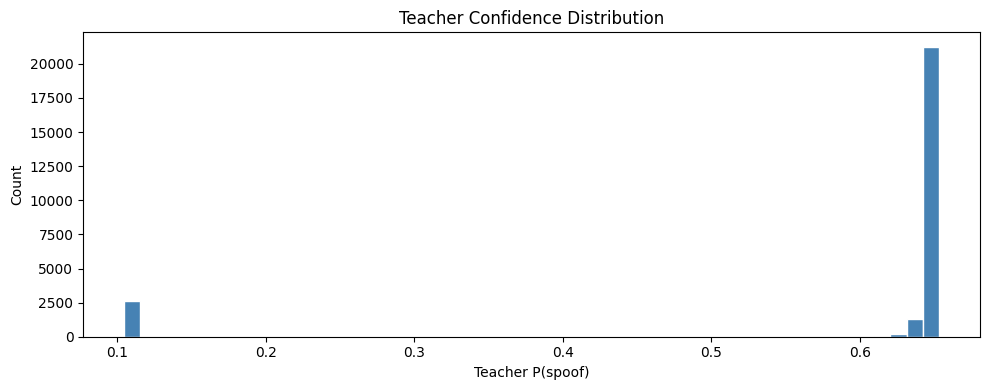

In [87]:
# Visualize teacher confidence
probs = F.softmax(teacher_logits, dim=-1).numpy()
plt.figure(figsize=(10, 4))
plt.hist(probs[:, 1], bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Teacher P(spoof)"); plt.ylabel("Count")
plt.title("Teacher Confidence Distribution")
plt.tight_layout(); plt.show()

## 4.4 Distillation Dataset

Same as regular dataset, but each sample also includes the
teacher's soft prediction for that audio file.

In [88]:
class DistillationDataset(Dataset):
    def __init__(self, protocol_df, audio_dir, metadata_df, teacher_logits_dict, is_train=True):
        self.protocol = protocol_df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.teacher_logits_dict = teacher_logits_dict
        self.is_train = is_train
        self.length_lookup = {}
        for _, r in metadata_df.iterrows():
            if r.get("status") == "success":
                self.length_lookup[r["audio_id"]] = int(r["original_length"])

    def __len__(self): return len(self.protocol)

    def __getitem__(self, idx):
        row = self.protocol.iloc[idx]
        audio, _ = torchaudio.load(str(self.audio_dir / f"{row['audio_id']}.flac"))
        audio = audio.squeeze(0)
        if self.is_train: audio = apply_augmentation(audio)
        mx = torch.max(torch.abs(audio))
        if mx > 0: audio = audio / mx
        ol = self.length_lookup.get(row["audio_id"], MAX_SAMPLES)
        mask = torch.zeros(MAX_SAMPLES); mask[:ol] = 1.0
        t_logit = self.teacher_logits_dict.get(row["audio_id"], torch.zeros(2))
        return {"audio": audio, "mask": mask,
                "label": torch.tensor(row["label_int"], dtype=torch.long),
                "teacher_logits": t_logit,
                "audio_id": row["audio_id"], "attack_type": row["attack_type"]}

In [89]:
teacher_logits_dict = {aid: teacher_logits[i] for i, aid in enumerate(teacher_ids)}

distill_dataset = DistillationDataset(
    train_protocol, PREPROCESSED_DIR/"train", metadata, teacher_logits_dict, is_train=True)
distill_loader = DataLoader(distill_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=True)

dev_dataset = ASVspoofDataset(dev_protocol, PREPROCESSED_DIR/"dev", metadata, is_train=False)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Distillation: {len(distill_loader)} batches | Dev: {len(dev_loader)} batches")

Distillation: 3173 batches | Dev: 3106 batches


## 4.5 Student Model (Frozen Wav2Vec2 + AASIST-L)

In [90]:
class AASSISTLBackend(nn.Module):
    """Lightweight AASIST (~85K params). Same idea, smaller dimensions."""
    def __init__(self, input_dim=1024, hidden_dim=64, n_heads=2, dropout=0.1):
        super().__init__()
        self.projection = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.GELU(),
                                         nn.LayerNorm(hidden_dim), nn.Dropout(dropout))
        self.spectral_gat = MultiHeadGraphAttention(hidden_dim, hidden_dim, n_heads, dropout)
        self.spectral_pool = nn.AdaptiveAvgPool1d(1)
        self.temporal_gat = MultiHeadGraphAttention(hidden_dim, hidden_dim, n_heads, dropout)
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        cd = hidden_dim * n_heads * 2
        self.hetero_attention = nn.Sequential(nn.Linear(cd, hidden_dim), nn.GELU(),
                                               nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.classifier = nn.Sequential(nn.Linear(hidden_dim, 32), nn.GELU(),
                                         nn.Dropout(dropout), nn.Linear(32, 2))
    def forward(self, f):
        x = self.projection(f)
        sp = self.spectral_pool(self.spectral_gat(x).transpose(1,2)).squeeze(-1)
        tp = self.temporal_pool(self.temporal_gat(x).transpose(1,2)).squeeze(-1)
        return self.classifier(self.hetero_attention(torch.cat([sp, tp], dim=-1)))

class StudentModel(nn.Module):
    def __init__(self, w2v_name="facebook/wav2vec2-xls-r-300m", hidden_dim=64):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(w2v_name)
        for p in self.wav2vec2.parameters(): p.requires_grad = False  # Frozen!
        self.backend = AASSISTLBackend(
            input_dim=self.wav2vec2.config.hidden_size, hidden_dim=hidden_dim)

    def forward(self, audio, mask=None):
        if mask is not None: mask = mask.long()
        with torch.no_grad():
            features = self.wav2vec2(audio, attention_mask=mask).last_hidden_state
        return self.backend(features)

In [91]:
def count_params(m, trainable=True):
    if trainable: return sum(p.numel() for p in m.parameters() if p.requires_grad)
    return sum(p.numel() for p in m.parameters())

student = StudentModel().to(DEVICE)
print(f"Student total params:     {count_params(student, False):,}")
print(f"Student trainable params: {count_params(student, True):,}")

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Student total params:     315,544,610
Student trainable params: 105,890


## 4.6 Loss Functions & Training Loop

In [92]:
class OCSoftmax(nn.Module):
    def __init__(self, m_real=0.9, m_fake=0.2, alpha=20.0):
        super().__init__()
        self.m_real = m_real; self.m_fake = m_fake; self.alpha = alpha
    def forward(self, logits, labels):
        rm = (labels == 0).float(); sm = (labels == 1).float()
        mod = logits.clone()
        mod[:, 0] -= self.m_real * rm; mod[:, 1] -= self.m_fake * sm
        return F.cross_entropy(self.alpha * mod, labels)

def kd_loss(student_logits, teacher_logits, temperature):
    s = F.log_softmax(student_logits / temperature, dim=-1)
    t = F.softmax(teacher_logits / temperature, dim=-1)
    return F.kl_div(s, t, reduction="batchmean") * (temperature ** 2)

def compute_eer(labels, scores):
    fpr, tpr, th = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr; idx = np.nanargmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2, th[idx]

@torch.no_grad()
def evaluate_student(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0; all_s, all_p, all_l = [], [], []
    for b in tqdm(dataloader, desc="Evaluating"):
        a = b["audio"].to(device); m = b["mask"].to(device); l = b["label"].to(device)
        logits = model(a, m); total_loss += criterion(logits, l).item()
        all_s.extend(F.softmax(logits, dim=-1)[:,1].cpu().numpy())
        all_p.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        all_l.extend(l.cpu().numpy())
    la = np.array(all_l); sa = np.array(all_s)
    eer, _ = compute_eer(la, sa)
    return {"loss": total_loss/len(dataloader), "eer": eer,
            "accuracy": accuracy_score(la, np.array(all_p))}

In [93]:
hard_criterion = OCSoftmax().to(DEVICE)
optimizer = torch.optim.AdamW(student.backend.parameters(), lr=LEARNING_RATE_BACKEND,
                               weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# --- Check for existing student checkpoint ---
STUDENT_CKPT_PATH = CHECKPOINT_DIR / "student_latest.pt"
STUDENT_BEST_PATH = CHECKPOINT_DIR / "student_best.pt"

start_epoch = 1
best_student_eer = float("inf")
history = {"train_loss": [], "hard_loss": [], "kd_loss": [],
           "train_acc": [], "dev_eer": [], "dev_loss": []}

if STUDENT_CKPT_PATH.exists():
    print("Found student checkpoint! Resuming...")
    ckpt = torch.load(str(STUDENT_CKPT_PATH), map_location=DEVICE)
    student.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_student_eer = ckpt["best_dev_eer"]
    history = ckpt["history"]
    print(f"Resuming from epoch {start_epoch} (best EER: {best_student_eer*100:.2f}%)")
else:
    print("No student checkpoint found. Starting fresh.")

No student checkpoint found. Starting fresh.


In [94]:
print("=" * 60)
print(f"STUDENT TRAINING (KD): Epochs {start_epoch} to {NUM_EPOCHS}")
print(f"  Temperature: {KD_TEMPERATURE} | Alpha: {KD_ALPHA}")
print("=" * 60)

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\n{'='*40} Epoch {epoch}/{NUM_EPOCHS} {'='*40}")

    student.train()
    ep_loss, ep_hard, ep_kd = 0, 0, 0
    ep_preds, ep_labels = [], []

    pbar = tqdm(distill_loader, desc=f"Epoch {epoch} [Student]")
    for batch in pbar:
        audio = batch["audio"].to(DEVICE); mask = batch["mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE); t_logits = batch["teacher_logits"].to(DEVICE)

        optimizer.zero_grad()
        s_logits = student(audio, mask)
        h_loss = hard_criterion(s_logits, labels)
        k_loss = kd_loss(s_logits, t_logits, KD_TEMPERATURE)
        loss = KD_ALPHA * h_loss + (1 - KD_ALPHA) * k_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        optimizer.step()

        ep_loss += loss.item(); ep_hard += h_loss.item(); ep_kd += k_loss.item()
        ep_preds.extend(torch.argmax(s_logits, dim=-1).cpu().numpy())
        ep_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    n = len(distill_loader)
    t_loss, t_hard, t_kd = ep_loss/n, ep_hard/n, ep_kd/n
    t_acc = accuracy_score(ep_labels, ep_preds)

    dev_res = evaluate_student(student, dev_loader, hard_criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(t_loss); history["hard_loss"].append(t_hard)
    history["kd_loss"].append(t_kd); history["train_acc"].append(t_acc)
    history["dev_eer"].append(dev_res["eer"]); history["dev_loss"].append(dev_res["loss"])

    print(f"  Loss: {t_loss:.4f} (Hard: {t_hard:.4f}, KD: {t_kd:.4f})")
    print(f"  Train Acc: {t_acc:.4f} | Dev EER: {dev_res['eer']*100:.2f}%")

    if dev_res["eer"] < best_student_eer:
        best_student_eer = dev_res["eer"]
        torch.save({"epoch": epoch, "model_state_dict": student.state_dict(),
                     "dev_eer": best_student_eer}, str(STUDENT_BEST_PATH))
        print(f"  ★ New best student! (EER: {best_student_eer*100:.2f}%)")

    torch.save({"epoch": epoch, "model_state_dict": student.state_dict(),
                 "optimizer_state_dict": optimizer.state_dict(),
                 "scheduler_state_dict": scheduler.state_dict(),
                 "best_dev_eer": best_student_eer, "history": history},
               str(STUDENT_CKPT_PATH))
    print(f"  Checkpoint saved (epoch {epoch})")

print(f"\n{'='*60}")
print(f"STUDENT TRAINING COMPLETE! Best Dev EER: {best_student_eer*100:.2f}%")
print(f"{'='*60}")

STUDENT TRAINING (KD): Epochs 1 to 10
  Temperature: 3.0 | Alpha: 0.5

======================================== Epoch 1/10 ========================================


Evaluating: 100%|██████████| 3106/3106 [32:20<00:00,  1.60it/s]


  Loss: 1.2858 (Hard: 2.4948, KD: 0.0768)
  Train Acc: 0.9010 | Dev EER: 12.56%
  ★ New best student! (EER: 12.56%)
  Checkpoint saved (epoch 1)

======================================== Epoch 2/10 ========================================


Evaluating: 100%|██████████| 3106/3106 [32:20<00:00,  1.60it/s]


  Loss: 1.0828 (Hard: 2.1036, KD: 0.0620)
  Train Acc: 0.9150 | Dev EER: 7.26%
  ★ New best student! (EER: 7.26%)
  Checkpoint saved (epoch 2)

======================================== Epoch 3/10 ========================================


...

  Loss: 1.0044 (Hard: 1.9523, KD: 0.0564)
  Train Acc: 0.9228 | Dev EER: 9.14%
  Checkpoint saved (epoch 3)

======================================== Epoch 4/10 ========================================


Evaluating: 100%|██████████| 3106/3106 [32:19<00:00,  1.60it/s]


  Loss: 0.9360 (Hard: 1.8189, KD: 0.0531)
  Train Acc: 0.9279 | Dev EER: 9.69%
  Checkpoint saved (epoch 4)

======================================== Epoch 5/10 ========================================


Epoch 5 [Student]:   3%|▎         | 100/3173 [01:01<31:14,  1.64it/s, loss=1.8589]


KeyboardInterrupt: 

## 4.7 Training Plots

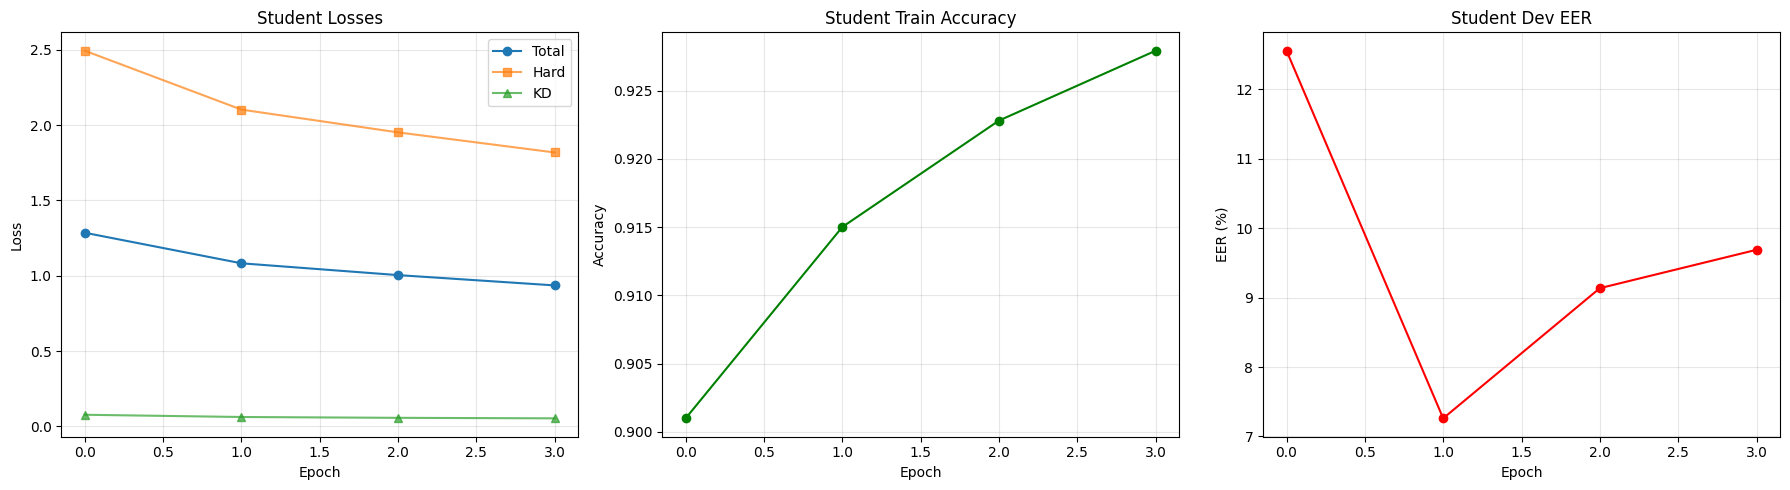


✅ Notebook 4 complete. Proceed to Notebook 5: Evaluation.


In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], "o-", label="Total")
axes[0].plot(history["hard_loss"], "s-", alpha=0.7, label="Hard")
axes[0].plot(history["kd_loss"], "^-", alpha=0.7, label="KD")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Student Losses"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], "o-", color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Student Train Accuracy"); axes[1].grid(True, alpha=0.3)

axes[2].plot([e*100 for e in history["dev_eer"]], "o-", color="red")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("EER (%)")
axes[2].set_title("Student Dev EER"); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / "student_training_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Notebook 4 complete. Proceed to Notebook 5: Evaluation.")

#Setup Evalutation

In [96]:
import os, json, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import torchaudio
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Model
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [97]:
PREPROCESSED_DIR = Path("/content/preprocessed")
CHECKPOINT_DIR = Path("/content/drive/MyDrive/deepfake_project/checkpoints")
RESULTS_DIR = Path("/content/drive/MyDrive/deepfake_project/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16000; MAX_DURATION = 6; MAX_SAMPLES = TARGET_SR * MAX_DURATION
BATCH_SIZE = 8; SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Verify everything exists
assert PREPROCESSED_DIR.exists(), "Run Notebook 1 first!"
assert (CHECKPOINT_DIR / "teacher_best.pt").exists(), "Run Notebook 3 first!"
assert (CHECKPOINT_DIR / "student_best.pt").exists(), "Run Notebook 4 first!"
print("All checkpoints found ✓")

Device: cuda
All checkpoints found ✓


In [98]:
def load_protocol(path):
    df = pd.read_csv(path, sep=" ", header=None,
                     names=["speaker_id", "audio_id", "system_id", "attack_type", "label"])
    df["label_int"] = (df["label"] == "spoof").astype(int)
    return df

PROTOCOL_DIR = PREPROCESSED_DIR / "protocols"
eval_protocol = load_protocol(PROTOCOL_DIR / "ASVspoof2019.LA.cm.eval.trl.txt")
metadata = pd.read_csv(PREPROCESSED_DIR / "metadata.csv")

print(f"Eval samples: {len(eval_protocol)}")
print(f"Attack types: {sorted(eval_protocol['attack_type'].unique())}")

Eval samples: 71237
Attack types: ['-', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']


In [99]:
class ASVspoofDataset(Dataset):
    def __init__(self, protocol_df, audio_dir, metadata_df):
        self.protocol = protocol_df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.length_lookup = {}
        for _, r in metadata_df.iterrows():
            if r.get("status") == "success":
                self.length_lookup[r["audio_id"]] = int(r["original_length"])
    def __len__(self): return len(self.protocol)
    def __getitem__(self, idx):
        row = self.protocol.iloc[idx]
        audio, _ = torchaudio.load(str(self.audio_dir / f"{row['audio_id']}.flac"))
        audio = audio.squeeze(0)
        mx = torch.max(torch.abs(audio))
        if mx > 0: audio = audio / mx
        ol = self.length_lookup.get(row["audio_id"], MAX_SAMPLES)
        mask = torch.zeros(MAX_SAMPLES); mask[:ol] = 1.0
        return {"audio": audio, "mask": mask,
                "label": torch.tensor(row["label_int"], dtype=torch.long),
                "audio_id": row["audio_id"], "attack_type": row["attack_type"]}

eval_dataset = ASVspoofDataset(eval_protocol, PREPROCESSED_DIR / "eval", metadata)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
print(f"Eval: {len(eval_dataset)} samples, {len(eval_loader)} batches")

Eval: 71237 samples, 8905 batches


## 5.3 Model Architecture (for loading checkpoints)

In [100]:
class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.a_src = nn.Linear(out_dim, 1, bias=False)
        self.a_dst = nn.Linear(out_dim, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        h = self.W(x)
        attn = self.leaky_relu(self.a_src(h) + self.a_dst(h).transpose(-2,-1))
        return torch.bmm(self.dropout(F.softmax(attn, dim=-1)), h)

class MultiHeadGraphAttention(nn.Module):
    def __init__(self, in_dim, out_dim, n_heads=2, dropout=0.1):
        super().__init__()
        self.heads = nn.ModuleList([GraphAttentionLayer(in_dim, out_dim, dropout) for _ in range(n_heads)])
        self.norm = nn.LayerNorm(out_dim * n_heads)
    def forward(self, x):
        return self.norm(torch.cat([h(x) for h in self.heads], dim=-1))

class AASSISTBackend(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=160, n_heads=2, dropout=0.1):
        super().__init__()
        self.projection = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.GELU(),
                                         nn.LayerNorm(hidden_dim), nn.Dropout(dropout))
        self.spectral_gat = MultiHeadGraphAttention(hidden_dim, hidden_dim, n_heads, dropout)
        self.spectral_pool = nn.AdaptiveAvgPool1d(1)
        self.temporal_gat = MultiHeadGraphAttention(hidden_dim, hidden_dim, n_heads, dropout)
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        cd = hidden_dim * n_heads * 2
        self.hetero_attention = nn.Sequential(nn.Linear(cd, hidden_dim), nn.GELU(),
                                               nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.classifier = nn.Sequential(nn.Linear(hidden_dim, 64), nn.GELU(),
                                         nn.Dropout(dropout), nn.Linear(64, 2))
    def forward(self, f):
        x = self.projection(f)
        sp = self.spectral_pool(self.spectral_gat(x).transpose(1,2)).squeeze(-1)
        tp = self.temporal_pool(self.temporal_gat(x).transpose(1,2)).squeeze(-1)
        return self.classifier(self.hetero_attention(torch.cat([sp, tp], dim=-1)))

class AASSISTLBackend(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=64, n_heads=2, dropout=0.1):
        super().__init__()
        self.projection = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.GELU(),
                                         nn.LayerNorm(hidden_dim), nn.Dropout(dropout))
        self.spectral_gat = MultiHeadGraphAttention(hidden_dim, hidden_dim, n_heads, dropout)
        self.spectral_pool = nn.AdaptiveAvgPool1d(1)
        self.temporal_gat = MultiHeadGraphAttention(hidden_dim, hidden_dim, n_heads, dropout)
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        cd = hidden_dim * n_heads * 2
        self.hetero_attention = nn.Sequential(nn.Linear(cd, hidden_dim), nn.GELU(),
                                               nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.classifier = nn.Sequential(nn.Linear(hidden_dim, 32), nn.GELU(),
                                         nn.Dropout(dropout), nn.Linear(32, 2))
    def forward(self, f):
        x = self.projection(f)
        sp = self.spectral_pool(self.spectral_gat(x).transpose(1,2)).squeeze(-1)
        tp = self.temporal_pool(self.temporal_gat(x).transpose(1,2)).squeeze(-1)
        return self.classifier(self.hetero_attention(torch.cat([sp, tp], dim=-1)))

class TeacherModel(nn.Module):
    def __init__(self, w2v_name="facebook/wav2vec2-xls-r-300m", hidden_dim=160):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(w2v_name)
        self.wav2vec2.feature_extractor._freeze_parameters()
        self.backend = AASSISTBackend(input_dim=self.wav2vec2.config.hidden_size, hidden_dim=hidden_dim)
    def forward(self, audio, mask=None):
        if mask is not None: mask = mask.long()
        return self.backend(self.wav2vec2(audio, attention_mask=mask).last_hidden_state)

class StudentModel(nn.Module):
    def __init__(self, w2v_name="facebook/wav2vec2-xls-r-300m", hidden_dim=64):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(w2v_name)
        for p in self.wav2vec2.parameters(): p.requires_grad = False
        self.backend = AASSISTLBackend(input_dim=self.wav2vec2.config.hidden_size, hidden_dim=hidden_dim)
    def forward(self, audio, mask=None):
        if mask is not None: mask = mask.long()
        with torch.no_grad():
            features = self.wav2vec2(audio, attention_mask=mask).last_hidden_state
        return self.backend(features)

In [105]:
def count_params(m, trainable=True):
    if trainable: return sum(p.numel() for p in m.parameters() if p.requires_grad)
    return sum(p.numel() for p in m.parameters())

print("Loading models...")
teacher = TeacherModel().to(DEVICE)
teacher.load_state_dict(torch.load(str(CHECKPOINT_DIR/"teacher_best.pt"), map_location=DEVICE, weights_only=False)["model_state_dict"])
teacher.eval()
print(f"Teacher loaded. Trainable params: {count_params(teacher, True):,}")

student = StudentModel().to(DEVICE)
student.load_state_dict(torch.load(str(CHECKPOINT_DIR/"student_best.pt"), map_location=DEVICE, weights_only=False)["model_state_dict"])
student.eval()
print(f"Student loaded. Trainable params: {count_params(student, True):,}")

Loading models...


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Teacher loaded. Trainable params: 311,636,578


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Student loaded. Trainable params: 105,890


## 5.4 Evaluation Metrics

In [106]:
def compute_eer(labels, scores):
    fpr, tpr, th = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr; idx = np.nanargmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2, th[idx]

def compute_min_tdcf(labels, scores, Pspoof=0.05, Cmiss=1, Cfa=10):
    """
    Simplified min-tDCF (CM scores only).
    The full version requires ASV scores which are not available here.
    """
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    beta = Pspoof / (1 - Pspoof)
    return np.min(Cmiss * fnr + Cfa * beta * fpr)

@torch.no_grad()
def full_evaluation(model, dataloader, device, desc="Eval"):
    model.eval()
    all_scores, all_preds, all_labels = [], [], []
    all_ids, all_attacks = [], []

    for batch in tqdm(dataloader, desc=desc):
        audio = batch["audio"].to(device); mask = batch["mask"].to(device)
        labels = batch["label"].to(device)
        logits = model(audio, mask)
        probs = F.softmax(logits, dim=-1)
        all_scores.extend(probs[:, 1].cpu().numpy())
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_ids.extend(batch["audio_id"])
        all_attacks.extend(batch["attack_type"])

    labels = np.array(all_labels); scores = np.array(all_scores); preds = np.array(all_preds)
    eer, eer_th = compute_eer(labels, scores)
    return {
        "eer": eer, "eer_threshold": eer_th,
        "min_tdcf": compute_min_tdcf(labels, scores),
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "labels": labels, "scores": scores, "preds": preds,
        "attacks": np.array(all_attacks),
    }

## 5.5 Run Evaluation

In [107]:
print("=" * 60)
print("EVALUATING ON EVAL SET (Unseen Attacks A07-A19)")
print("=" * 60)

print("\nTeacher evaluation...")
teacher_res = full_evaluation(teacher, eval_loader, DEVICE, "Teacher")

print("\nStudent evaluation...")
student_res = full_evaluation(student, eval_loader, DEVICE, "Student")

EVALUATING ON EVAL SET (Unseen Attacks A07-A19)

Teacher evaluation...


Teacher: 100%|██████████| 8905/8905 [1:32:52<00:00,  1.60it/s]



Student evaluation...


Student: 100%|██████████| 8905/8905 [1:32:41<00:00,  1.60it/s]


## 5.6 Results Comparison

In [108]:
print("\n" + "=" * 60)
print("TEACHER vs STUDENT — EVAL SET RESULTS")
print("=" * 60)

rows = [
    ("EER (%)",     f"{teacher_res['eer']*100:.2f}%",    f"{student_res['eer']*100:.2f}%"),
    ("min-tDCF",    f"{teacher_res['min_tdcf']:.4f}",    f"{student_res['min_tdcf']:.4f}"),
    ("Accuracy",    f"{teacher_res['accuracy']:.4f}",     f"{student_res['accuracy']:.4f}"),
    ("Precision",   f"{teacher_res['precision']:.4f}",    f"{student_res['precision']:.4f}"),
    ("Recall",      f"{teacher_res['recall']:.4f}",       f"{student_res['recall']:.4f}"),
    ("F1-Score",    f"{teacher_res['f1']:.4f}",           f"{student_res['f1']:.4f}"),
    ("Params (trainable)", f"{count_params(teacher,True):,}", f"{count_params(student,True):,}"),
]

print(f"\n{'Metric':<20} {'Teacher':>14} {'Student':>14}")
print("-" * 50)
for name, t_val, s_val in rows:
    print(f"{name:<20} {t_val:>14} {s_val:>14}")


TEACHER vs STUDENT — EVAL SET RESULTS

Metric                      Teacher        Student
--------------------------------------------------
EER (%)                       0.50%          7.74%
min-tDCF                     0.0060         0.1096
Accuracy                     0.9507         0.7397
Precision                    0.9999         0.9940
Recall                       0.9451         0.7140
F1-Score                     0.9718         0.8311
Params (trainable)      311,636,578        105,890


## 5.7 Confusion Matrices

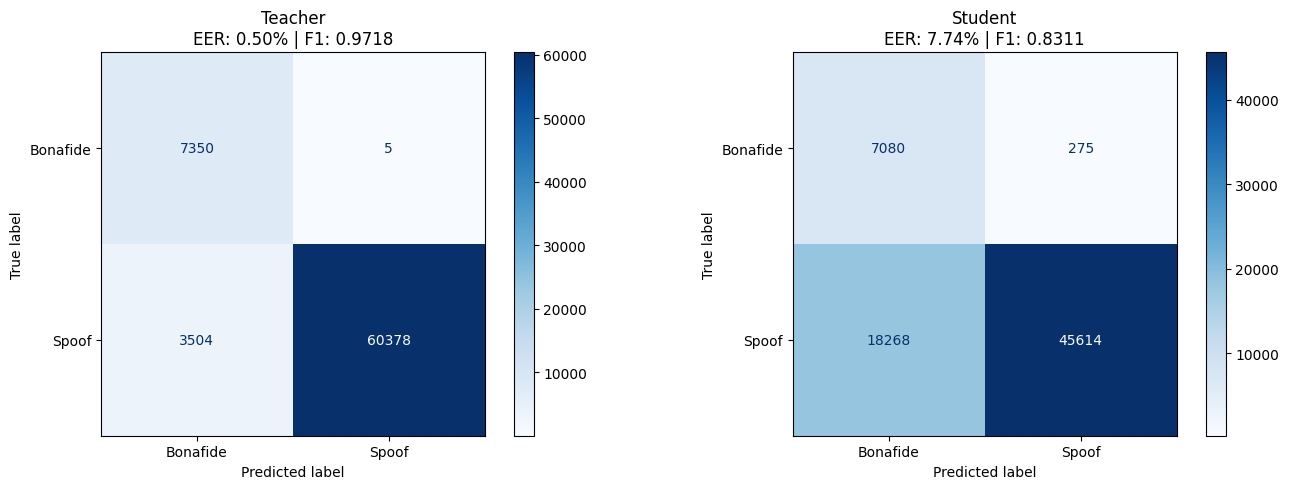

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title in [(axes[0], teacher_res, "Teacher"), (axes[1], student_res, "Student")]:
    cm = confusion_matrix(res["labels"], res["preds"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Bonafide", "Spoof"])
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"{title}\nEER: {res['eer']*100:.2f}% | F1: {res['f1']:.4f}")

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5.8 Score Distributions

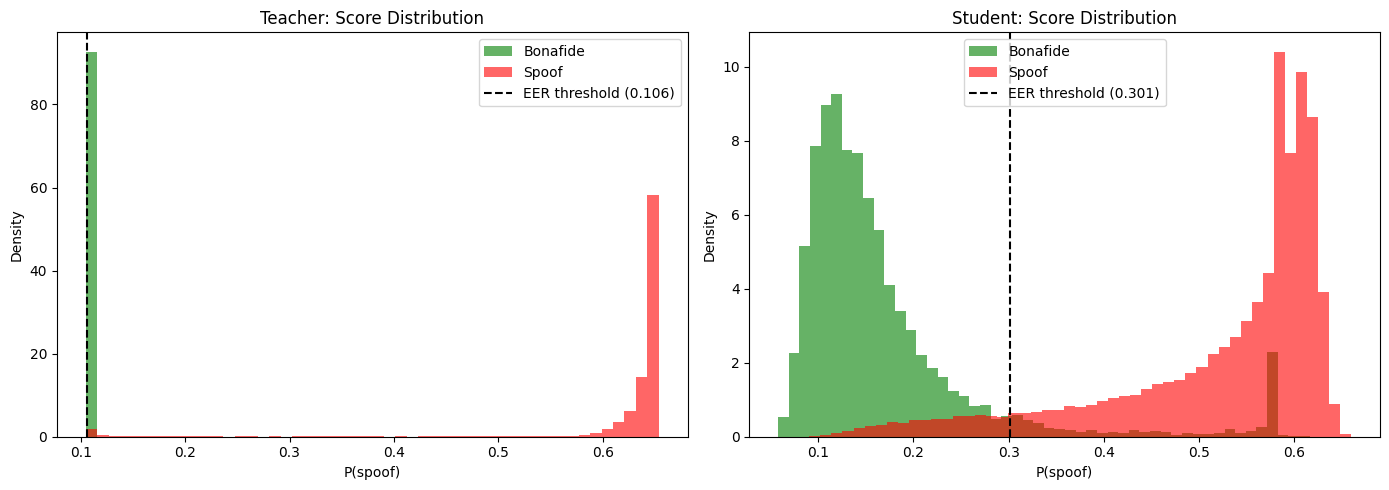

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title in [(axes[0], teacher_res, "Teacher"), (axes[1], student_res, "Student")]:
    bon = res["scores"][res["labels"] == 0]
    spf = res["scores"][res["labels"] == 1]
    ax.hist(bon, bins=50, alpha=0.6, label="Bonafide", color="green", density=True)
    ax.hist(spf, bins=50, alpha=0.6, label="Spoof", color="red", density=True)
    ax.axvline(res["eer_threshold"], color="black", linestyle="--",
               label=f"EER threshold ({res['eer_threshold']:.3f})")
    ax.set_xlabel("P(spoof)"); ax.set_ylabel("Density")
    ax.set_title(f"{title}: Score Distribution"); ax.legend()

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "score_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5.9 Per-Attack EER Analysis

In [111]:
def per_attack_eer(results):
    labels = results["labels"]; scores = results["scores"]; attacks = results["attacks"]
    rows = []
    for attack in sorted(set(attacks)):
        if attack == "-": continue
        mask = (attacks == attack) | (labels == 0)
        sub_l = labels[mask]; sub_s = scores[mask]
        if len(np.unique(sub_l)) < 2: continue
        eer, _ = compute_eer(sub_l, sub_s)
        rows.append({"Attack": attack, "Samples": int((attacks == attack).sum()),
                      "EER (%)": round(eer * 100, 2)})
    return pd.DataFrame(rows)

In [112]:
print("\nPer-Attack EER — Teacher:")
t_attacks = per_attack_eer(teacher_res)
print(t_attacks.to_string(index=False))

print("\nPer-Attack EER — Student:")
s_attacks = per_attack_eer(student_res)
print(s_attacks.to_string(index=False))


Per-Attack EER — Teacher:
Attack  Samples  EER (%)
   A07     4914     0.12
   A08     4914     0.70
   A09     4914     0.01
   A10     4914     0.65
   A11     4914     0.26
   A12     4914     0.17
   A13     4914     0.00
   A14     4914     0.15
   A15     4914     0.41
   A16     4914     0.02
   A17     4914     0.33
   A18     4914     0.99
   A19     4914     0.15

Per-Attack EER — Student:
Attack  Samples  EER (%)
   A07     4914     6.78
   A08     4914     5.36
   A09     4914     2.61
   A10     4914    15.35
   A11     4914     2.97
   A12     4914     4.22
   A13     4914     0.44
   A14     4914     3.11
   A15     4914     5.35
   A16     4914     6.24
   A17     4914     6.82
   A18     4914     4.75
   A19     4914    19.72


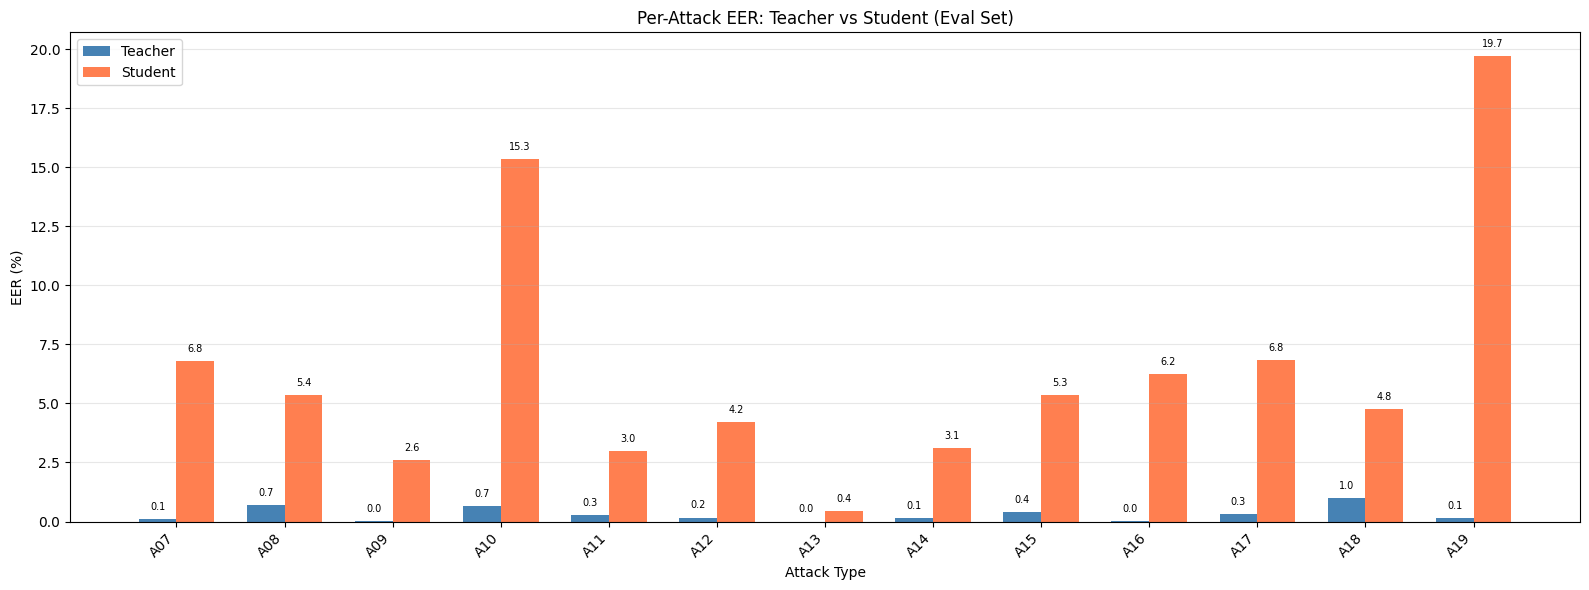

In [113]:
# Bar chart
if not t_attacks.empty and not s_attacks.empty:
    merged = t_attacks[["Attack","EER (%)"]].rename(columns={"EER (%)":"Teacher"}).merge(
        s_attacks[["Attack","EER (%)"]].rename(columns={"EER (%)":"Student"}), on="Attack")

    x = np.arange(len(merged)); w = 0.35
    fig, ax = plt.subplots(figsize=(16, 6))
    b1 = ax.bar(x - w/2, merged["Teacher"], w, label="Teacher", color="steelblue")
    b2 = ax.bar(x + w/2, merged["Student"], w, label="Student", color="coral")
    ax.set_xlabel("Attack Type"); ax.set_ylabel("EER (%)")
    ax.set_title("Per-Attack EER: Teacher vs Student (Eval Set)")
    ax.set_xticks(x); ax.set_xticklabels(merged["Attack"], rotation=45, ha="right")
    ax.legend(); ax.grid(True, alpha=0.3, axis="y")

    for bar in b1:
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
    for bar in b2:
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / "per_attack_eer.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 5.10 Hardest & Easiest Attacks

In [114]:
if not s_attacks.empty:
    print("Top 5 HARDEST attacks for Student:")
    print(s_attacks.nlargest(5, "EER (%)").to_string(index=False))
    print("\nTop 5 EASIEST attacks for Student:")
    print(s_attacks.nsmallest(5, "EER (%)").to_string(index=False))

Top 5 HARDEST attacks for Student:
Attack  Samples  EER (%)
   A19     4914    19.72
   A10     4914    15.35
   A17     4914     6.82
   A07     4914     6.78
   A16     4914     6.24

Top 5 EASIEST attacks for Student:
Attack  Samples  EER (%)
   A13     4914     0.44
   A09     4914     2.61
   A11     4914     2.97
   A14     4914     3.11
   A12     4914     4.22


## 5.11 Save All Results

In [115]:
summary = {
    "teacher": {k: float(teacher_res[k]) for k in ["eer","min_tdcf","accuracy","precision","recall","f1"]},
    "student": {k: float(student_res[k]) for k in ["eer","min_tdcf","accuracy","precision","recall","f1"]},
    "teacher_params": count_params(teacher, True),
    "student_params": count_params(student, True),
    "config": {"max_duration": MAX_DURATION, "target_sr": TARGET_SR, "seed": SEED},
}

with open(str(RESULTS_DIR / "results_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

if not t_attacks.empty:
    t_attacks.to_csv(str(RESULTS_DIR / "teacher_per_attack.csv"), index=False)
if not s_attacks.empty:
    s_attacks.to_csv(str(RESULTS_DIR / "student_per_attack.csv"), index=False)

In [116]:
print("\n" + "=" * 60)
print("PROJECT COMPLETE!")
print("=" * 60)
print(f"""
Files saved to Google Drive ({RESULTS_DIR}):
  results_summary.json
  confusion_matrices.png
  score_distributions.png
  per_attack_eer.png
  teacher_per_attack.csv
  student_per_attack.csv

Checkpoints ({CHECKPOINT_DIR}):
  teacher_best.pt
  student_best.pt
""")


PROJECT COMPLETE!

Files saved to Google Drive (/content/drive/MyDrive/deepfake_project/results):
  results_summary.json
  confusion_matrices.png
  score_distributions.png
  per_attack_eer.png
  teacher_per_attack.csv
  student_per_attack.csv

Checkpoints (/content/drive/MyDrive/deepfake_project/checkpoints):
  teacher_best.pt
  student_best.pt

